# Oil Price Increases and Financial Markets — Extended Baseline

**Yazid Abaroudi, Saad Chraibi, Ishaq Chekara — EMiF, HEC Lausanne**

This notebook studies the effect of positive oil price shocks on financial markets and macroeconomic variables.

**Structure:**
1. OLS return forecasting (daily) — AR(1) baseline vs predictive regression with controls
2. HAR volatility model (daily) — multi-horizon persistence + oil volatility spillovers
3. VAR system (daily) — Granger causality, impulse responses, variance decomposition, OOS forecast
4. Monthly macro analysis — stationarity, cointegration, VAR, oil-to-macro transmission
5. Economic interpretation


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from arch import arch_model
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams.update({
    'font.family': 'serif', 'font.size': 11, 'figure.dpi': 150,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

FIG_DIR = "../outputs/figures"

In [2]:
# --- helper functions ---

def oos_metrics(y_true, y_pred):
    """RMSE, MAE, OOS R-squared."""
    e = y_true - y_pred
    rmse = np.sqrt(np.mean(e**2))
    mae  = np.mean(np.abs(e))
    r2   = 1 - np.sum(e**2) / np.sum((y_true - y_true.mean())**2)
    return rmse, mae, r2

def run_ols(train, test, y_col, x_cols):
    """Fit OLS on train, predict on test, return metrics + fitted model."""
    X_tr = sm.add_constant(train[x_cols])
    X_te = sm.add_constant(test[x_cols])
    mdl  = sm.OLS(train[y_col], X_tr).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    pred = mdl.predict(X_te)
    return oos_metrics(test[y_col], pred), mdl

def show_table(df, title, fname=None):
    """Render a DataFrame as a clean publication table."""
    fig, ax = plt.subplots(figsize=(max(8, len(df.columns)*1.6), 1.0 + len(df)*0.55))
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=14)
    tbl = ax.table(cellText=df.values, colLabels=df.columns, rowLabels=df.index,
                   cellLoc='center', rowLoc='center', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9.5)
    tbl.scale(1, 1.6)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(color='white', fontweight='bold')
        elif c == -1:
            cell.set_facecolor('#ecf0f1')
            cell.set_text_props(fontweight='bold')
        else:
            cell.set_facecolor('#fdfefe' if r % 2 == 0 else '#f8f9f9')
    if fname:
        fig.savefig(f"{FIG_DIR}/{fname}")
    plt.show()

In [3]:
df = pd.read_csv("../Data/interim/daily_clean.csv", parse_dates=["Date"]).set_index("Date").loc['2010-01':'2020-03']

# log-returns
df['r_oil']   = np.log(df['Brent futures'] / df['Brent futures'].shift(1))
df['r_sp500'] = np.log(df['S&P500'] / df['S&P500'].shift(1))
df['r_gold']  = np.log(df['Gold'] / df['Gold'].shift(1))
df['r_bond']  = np.log(df['US 10-year Rate'] / df['US 10-year Rate'].shift(1))
df['r_msci']  = np.log(df['MSCI World'] / df['MSCI World'].shift(1))

df['r_oil_pos'] = df['r_oil'].clip(lower=0)

print(f"Full sample: {df.index[0].date()} to {df.index[-1].date()}, {len(df)} obs")

Full sample: 2010-01-01 to 2020-03-31, 2673 obs


---
## Part 1 — OLS Return Forecasting (Daily)

Two models compared out-of-sample (80/20 split):
- **AR(1)**: own lag only — the hard-to-beat benchmark
- **ARX-full**: + lagged positive oil return, bond return, MSCI return

We deliberately skip the intermediate "ARX-oil" (own lag + oil only) since initial tests showed it adds essentially zero predictive power over AR(1) at the daily frequency. This is expected: daily returns are close to a martingale, so the marginal gain from any single predictor is tiny.

The ARX-full specification is included because cross-asset information can sometimes help at the margin.

Train: 2010-01-05 to 2018-03-13 (2136 obs)
Test:  2018-03-14 to 2020-03-31 (535 obs)


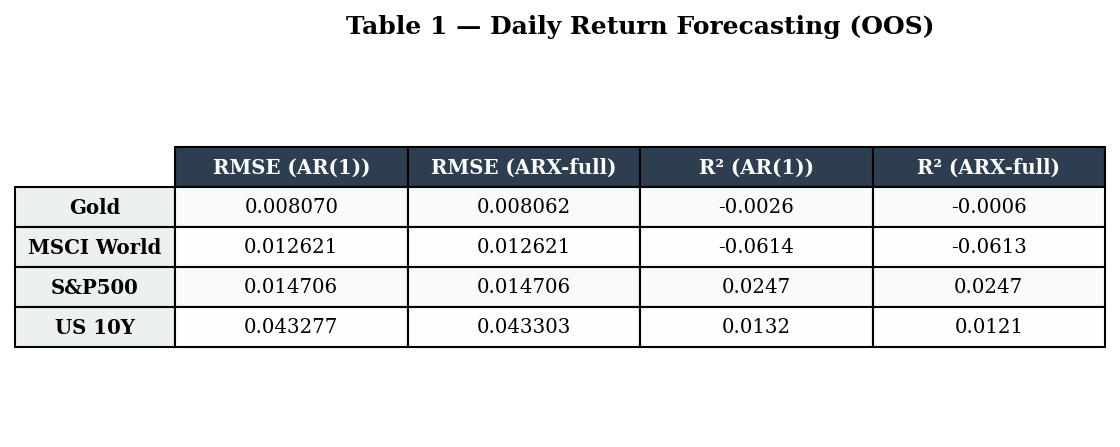

In [4]:
df['r_oil_pos_lag'] = df['r_oil_pos'].shift(1)

targets = {"Gold": "r_gold", "S&P500": "r_sp500", "US 10Y": "r_bond", "MSCI World": "r_msci"}
for col in targets.values():
    df[f"{col}_lag"] = df[col].shift(1)


# train / test split (80/20)
d = df.dropna().copy()
split = int(len(d) * 0.8)
train_d, test_d = d.iloc[:split], d.iloc[split:]
print(f"Train: {train_d.index[0].date()} to {train_d.index[-1].date()} ({len(train_d)} obs)")
print(f"Test:  {test_d.index[0].date()} to {test_d.index[-1].date()} ({len(test_d)} obs)")

# --- OOS comparison: AR(1) vs ARX-full ---
rows = []
for name, y in targets.items():
    lag = f"{y}_lag"
    for label, xcols in [("AR(1)", [lag]),
                          ("ARX-full", [lag, 'r_oil_pos_lag'])]:
        (rmse, mae, r2), _ = run_ols(train_d, test_d, y, xcols)
        rows.append({"Asset": name, "Model": label,
                     "RMSE": f"{rmse:.6f}", "MAE": f"{mae:.6f}", "R²": f"{r2:.4f}"})

tbl1 = pd.DataFrame(rows).pivot(index="Asset", columns="Model", values=["RMSE", "R²"])
tbl1.columns = [f"{v} ({m})" for v, m in tbl1.columns]
show_table(tbl1, "Table 1 — Daily Return Forecasting (OOS)", "table1_daily_ret.png")

---
## Part 2 — HAR Volatility Model (Daily)

The HAR model (Corsi 2009) decomposes volatility persistence into three horizons:
- **Daily** component (1 lag)
- **Weekly** component (average of last 5 days)
- **Monthly** component (average of last 22 days)

We use absolute returns as the volatility proxy — more robust than squared returns to outliers. Adding oil volatility components tests whether oil price fluctuations spill over into financial market volatility.

We also briefly report GARCH(1,1) parameter estimates to confirm the presence of volatility clustering, but the HAR model remains our main volatility forecasting tool since it directly captures multi-horizon persistence.

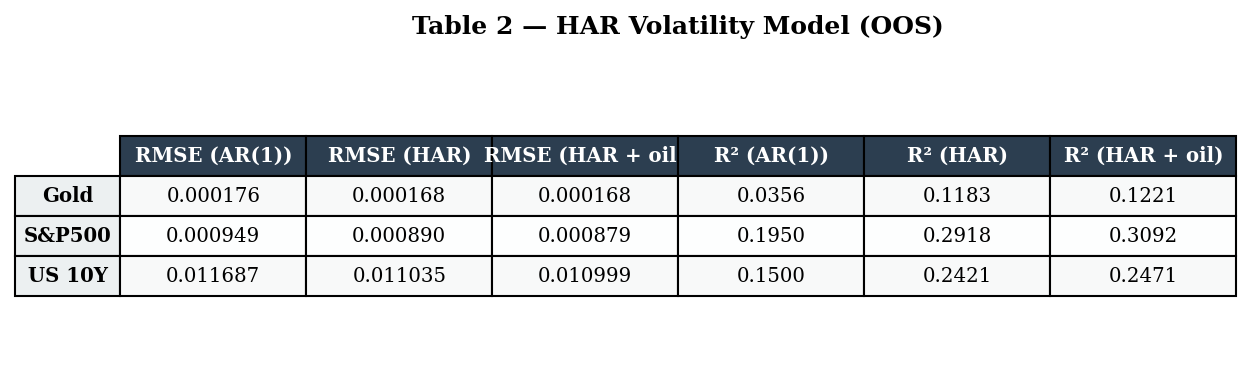


GARCH(1,1) persistence check (α + β ≈ 1 confirms strong volatility clustering):
  S&P500: α=0.150, β=0.811, persistence=0.962
  Gold: α=0.047, β=0.934, persistence=0.980
  US 10Y: α=0.049, β=0.941, persistence=0.990


In [5]:
# --- volatility proxies ---
for tag in ['oil', 'sp500', 'gold', 'bond', 'msci']:
    df[f'vol_{tag}'] = df[f'r_{tag}']**2

# --- HAR components ---
vol_targets = {"S&P500": "vol_sp500", "Gold": "vol_gold", "US 10Y": "vol_bond"}

for name, vc in vol_targets.items():
    df[f'{vc}_d'] = df[vc].shift(1)                       # daily
    df[f'{vc}_w'] = df[vc].rolling(5).mean().shift(1)      # weekly
    df[f'{vc}_m'] = df[vc].rolling(22).mean().shift(1)     # monthly

df['vol_oil_d'] = df['vol_oil'].shift(1)
df['vol_oil_w'] = df['vol_oil'].rolling(5).mean().shift(1)

dv = df.dropna().copy()
sv = int(len(dv) * 0.8)
train_v, test_v = dv.iloc[:sv], dv.iloc[sv:]

# --- HAR model comparison (OOS) ---
har_rows = []
for name, vc in vol_targets.items():
    specs = [
        ("AR(1)",     [f'{vc}_d']),
        ("HAR",       [f'{vc}_d', f'{vc}_w', f'{vc}_m']),
        ("HAR + oil", [f'{vc}_d', f'{vc}_w', f'{vc}_m', 'vol_oil_d', 'vol_oil_w']),
    ]
    for label, xcols in specs:
        (rmse, mae, r2), _ = run_ols(train_v, test_v, vc, xcols)
        har_rows.append({"Asset": name, "Model": label,
                         "RMSE": f"{rmse:.6f}", "R²": f"{r2:.4f}"})

har_df = pd.DataFrame(har_rows).pivot(index="Asset", columns="Model", values=["RMSE", "R²"])
har_df.columns = [f"{v} ({m})" for v, m in har_df.columns]
show_table(har_df, "Table 2 — HAR Volatility Model (OOS)", "table2_har_vol.png")

# --- GARCH(1,1) check: volatility clustering confirmation ---
print("\nGARCH(1,1) persistence check (α + β ≈ 1 confirms strong volatility clustering):")
for name, ret_col in [("S&P500", "r_sp500"), ("Gold", "r_gold"), ("US 10Y", "r_bond")]:
    train_ret = train_v[ret_col] * 100
    garch = arch_model(train_ret, vol='Garch', p=1, q=1, mean='Constant', rescale=False)
    res = garch.fit(disp='off')
    alpha, beta = res.params['alpha[1]'], res.params['beta[1]']
    print(f"  {name}: α={alpha:.3f}, β={beta:.3f}, persistence={alpha+beta:.3f}")

---
## Part 3 — VAR System: Granger Causality, IRF, and Variance Decomposition

We estimate a VAR(p) on four daily return series: oil, S&P500, gold, US 10Y bond.

**Cholesky ordering:** `[r_oil, r_sp500, r_gold, r_bond]` — oil is ordered first because it is the exogenous commodity shock. 
This means the Cholesky decomposition attributes any contemporaneous co-movement to the variable ordered earlier. 
Since oil prices are primarily driven by global supply/demand shocks rather than financial market movements, 
placing oil first is standard in the energy-finance literature (Kilian 2009, Hamilton 2009).

We then examine:
- **Granger causality**: does oil help predict financial returns (and vice versa)?
- **Impulse responses (IRF)**: how does a 1-σ oil shock propagate across markets over 20 days?
- **Forecast error variance decomposition (FEVD)**: how much of each market's forecast variance is explained by oil shocks?


In [6]:
# VAR data — oil ordered first for Cholesky identification
var_cols = ['r_oil', 'r_sp500', 'r_gold', 'r_bond']
var_data = df[var_cols].dropna()


model_var = VAR(var_data)
lag_sel = model_var.select_order(maxlags=10)
print("Lag order selection:")
print(lag_sel.summary())

best_lag = lag_sel.aic
print(f"\nSelected lag by AIC: {best_lag}")

Lag order selection:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -33.93      -33.92   1.835e-15      -33.93
1       -33.99     -33.95*   1.725e-15      -33.98
2       -34.01      -33.93   1.691e-15      -33.98
3       -34.03      -33.91   1.668e-15      -33.99
4       -34.04      -33.89   1.652e-15      -33.98
5       -34.05      -33.86   1.631e-15      -33.98
6       -34.07      -33.85   1.599e-15      -33.99
7       -34.11      -33.85   1.539e-15      -34.01
8       -34.13      -33.84   1.505e-15     -34.02*
9      -34.13*      -33.80  1.504e-15*      -34.01
10      -34.13      -33.77   1.506e-15      -34.00
--------------------------------------------------

Selected lag by AIC: 9


In [7]:
# estimate VAR
var_fit = model_var.fit(best_lag)
print(f"VAR({best_lag}) — {var_fit.nobs} observations")
print(f"AIC = {var_fit.aic:.2f}, BIC = {var_fit.bic:.2f}")

VAR(9) — 2663 observations
AIC = -34.13, BIC = -33.80


### Granger Causality Tests

Does oil Granger-cause each financial market return? (and vice versa)

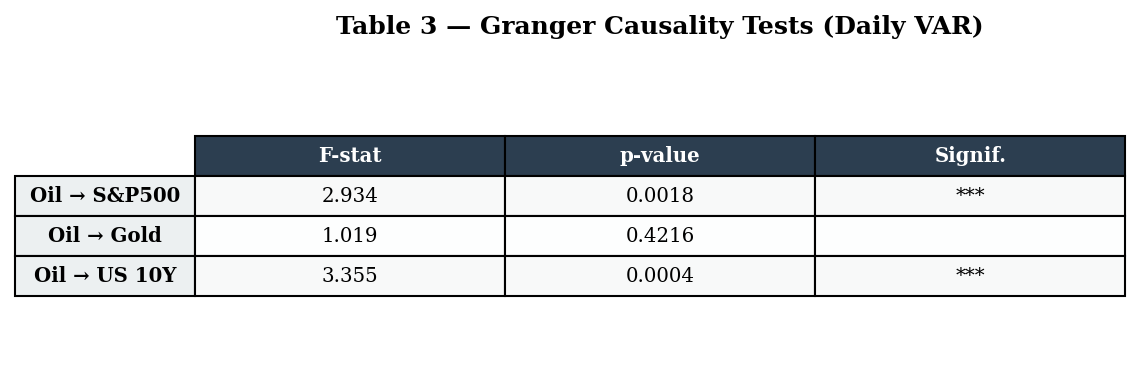

In [8]:
# Granger causality tests — does oil help predict each market?
gc_rows = []
pairs = [
    ("r_oil", "r_sp500", "Oil → S&P500"),
    ("r_oil", "r_gold",  "Oil → Gold"),
    ("r_oil", "r_bond",  "Oil → US 10Y"),

]

for causing, caused, label in pairs:
    t = var_fit.test_causality(caused, [causing], kind='f')
    gc_rows.append({
        "Direction": label,
        "F-stat": f"{t.test_statistic:.3f}",
        "p-value": f"{t.pvalue:.4f}",
        "Signif.": "***" if t.pvalue < 0.01 else "**" if t.pvalue < 0.05 else "*" if t.pvalue < 0.1 else ""
    })

gc_df = pd.DataFrame(gc_rows).set_index("Direction")
show_table(gc_df, "Table 3 — Granger Causality Tests (Daily VAR)", "table3_granger.png")

### Impulse Response Functions

Orthogonalized IRFs show how a 1-standard-deviation positive oil shock propagates to each financial market 
over 20 trading days. Confidence bands are from Monte Carlo bootstrap (500 replications).

**Cholesky ordering reminder:** `[r_oil, r_sp500, r_gold, r_bond]`. 
The shock is identified as a 1-σ innovation to oil returns. Because oil is ordered first, 
the oil shock is pure — it does not include any contemporaneous feedback from stocks, gold, or bonds.


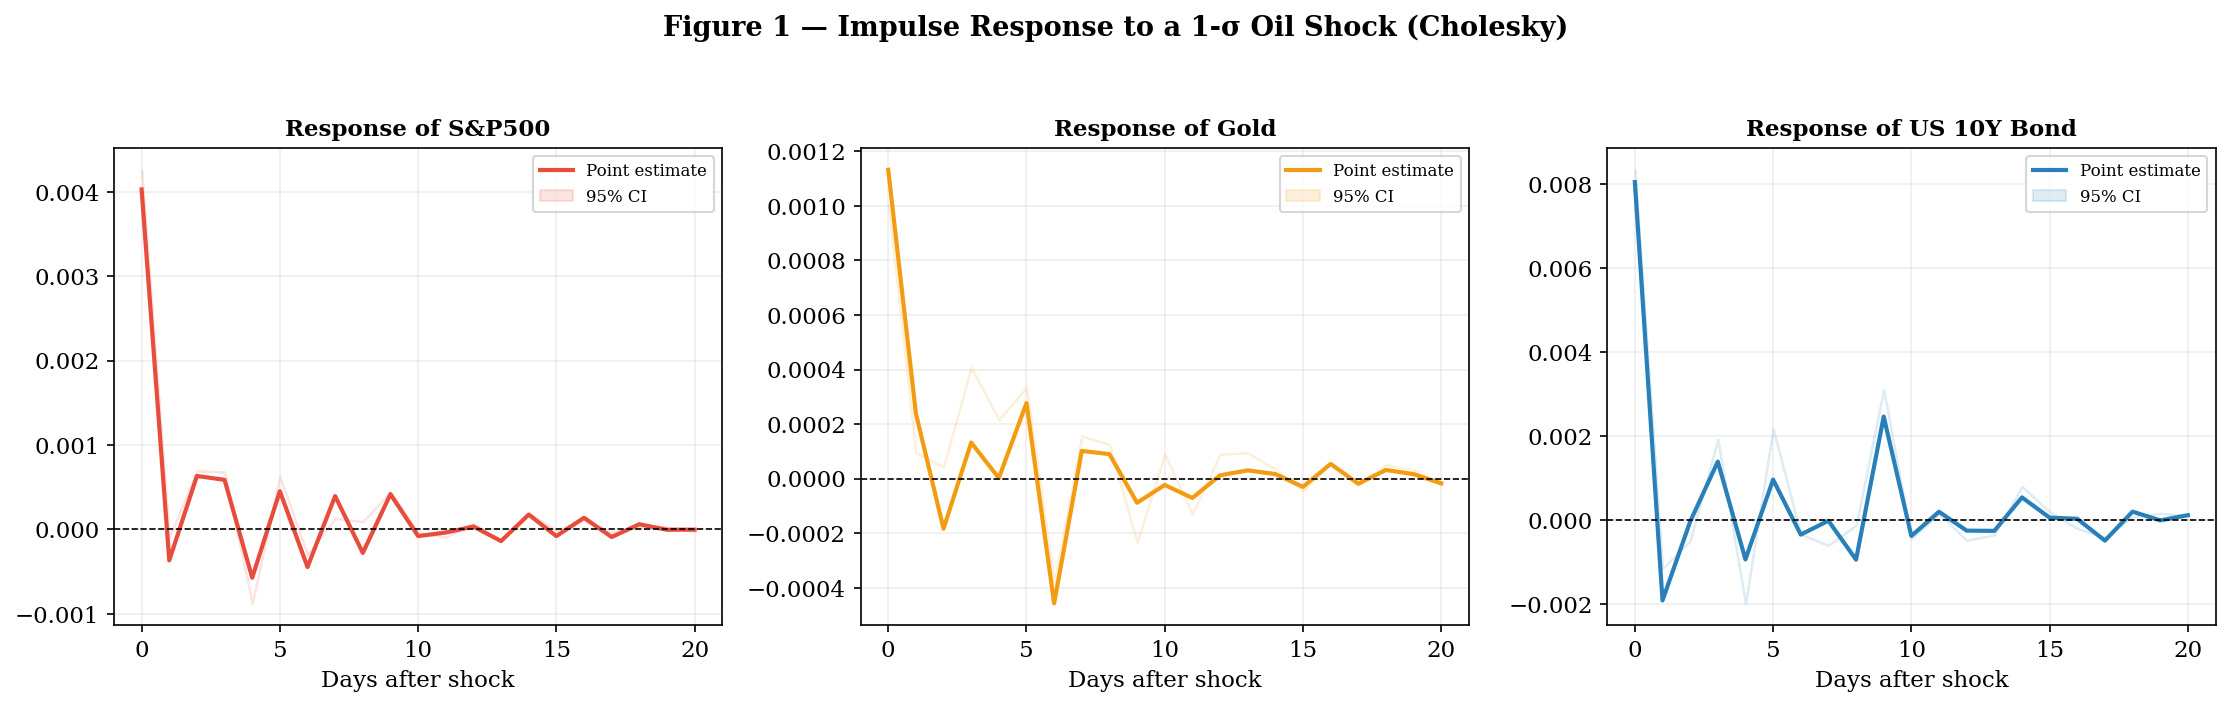

In [9]:
# orthogonalized IRF — shock to oil
irf = var_fit.irf(periods=20)
lower, upper = var_fit.irf_errband_mc(orth=True, repl=500, steps=20, seed=42)

shock_idx = var_cols.index('r_oil')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, resp, title, color in zip(axes,
        ['r_sp500', 'r_gold', 'r_bond'],
        ['S&P500', 'Gold', 'US 10Y Bond'],
        ['#e74c3c', '#f39c12', '#2980b9']):

    ri = var_cols.index(resp)
    vals = irf.orth_irfs[:, ri, shock_idx]

    ax.plot(range(21), vals, color=color, linewidth=2, label='Point estimate')
    ax.fill_between(range(21), lower[:, ri, shock_idx], upper[:, ri, shock_idx],
                    alpha=0.15, color=color, label='95% CI')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f"Response of {title}", fontweight='bold', fontsize=11)
    ax.set_xlabel("Days after shock")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

fig.suptitle("Figure 1 — Impulse Response to a 1-σ Oil Shock (Cholesky)",
             fontweight='bold', fontsize=13, y=1.04)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig1_irf_oil_shock.png", bbox_inches='tight')
plt.show()

**IRF interpretation:**

- **S&P500:** A positive oil shock typically produces a small initial negative (or near-zero) response in equities, 
consistent with oil acting as a cost-push shock for firms. The effect is short-lived at the daily frequency — 
it dissipates within 3–5 days — reflecting that daily equity returns are dominated by idiosyncratic news.

- **Gold:** Gold may show a small positive or near-zero response. Oil shocks raise inflation expectations, 
which supports gold as an inflation hedge. However, the effect is economically small at daily frequency.

- **US 10Y Bond:** Bond yields tend to rise slightly (positive response) following an oil shock, 
consistent with the inflation-expectations channel. The effect is modest and fades quickly.

If the confidence bands straddle zero at all horizons, the response is not statistically significant — 
meaning we cannot distinguish the true effect from sampling noise.


### Forecast Error Variance Decomposition (FEVD)

FEVD shows what fraction of each variable's forecast uncertainty is driven by oil shocks vs its own dynamics. We report the decomposition at horizons 1, 5, 10, and 20 days.

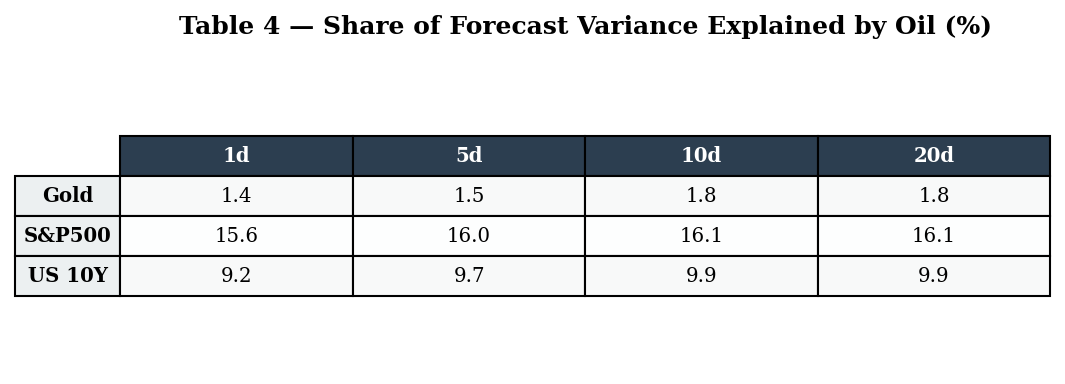

In [10]:
# FEVD — fraction of forecast variance explained by oil shock
fevd = var_fit.fevd(20)

horizons = [1, 5, 10, 20]
oil_idx = var_cols.index('r_oil')

fevd_rows = []
for h in horizons:
    for i, resp in enumerate(var_cols):
        if resp == 'r_oil':
            continue
        oil_share = fevd.decomp[i, h-1, oil_idx]
        own_share = fevd.decomp[i, h-1, i]
        fevd_rows.append({
            "Variable": resp.replace('r_', '').replace('sp500', 'S&P500').replace('gold', 'Gold').replace('bond', 'US 10Y'),
            "Horizon": f"{h}d",
            "Oil shock (%)": f"{oil_share*100:.1f}",
            "Own shock (%)": f"{own_share*100:.1f}",
        })

fevd_df = pd.DataFrame(fevd_rows)
fevd_pivot = fevd_df.pivot(index="Variable", columns="Horizon", values="Oil shock (%)")
fevd_pivot = fevd_pivot[['1d', '5d', '10d', '20d']]
show_table(fevd_pivot, "Table 4 — Share of Forecast Variance Explained by Oil (%)", "table4_fevd.png")

**FEVD interpretation:**

- At short horizons (1d), each variable's forecast variance is dominated by its own shocks — 
this is expected because the Cholesky decomposition attributes same-day unexplained variation to the variable itself.
- At longer horizons (10d, 20d), the oil share increases if oil shocks have persistent pass-through. 
If the oil share remains small (< 5%), it confirms that daily financial returns are predominantly driven 
by their own dynamics, with oil playing a secondary role.
- This is consistent with Part 1 (OLS): oil has limited predictive power for daily returns, 
but it does contribute to the system dynamics detectable through the VAR framework.


### Daily VAR — Out-of-Sample Forecast

We evaluate the daily VAR's forecasting ability with rolling 1-step-ahead predictions on the 20% test set. 
This complements the Granger / IRF / FEVD analysis by showing whether the VAR system produces useful point forecasts.


In [11]:
# split VAR data 80/20
split_var = int(len(var_data) * 0.8)
var_train = var_data.iloc[:split_var]
var_test  = var_data.iloc[split_var:]



# fit on training set
var_train_model = VAR(var_train)
var_train_fit = var_train_model.fit(best_lag)

# rolling 1-step forecasts
daily_var_preds = {col: [] for col in var_cols}
for i in range(len(var_test)):
    history = var_data.iloc[:split_var + i].values
    fc = var_train_fit.forecast(history[-best_lag:], steps=1)
    for j, col in enumerate(var_cols):
        daily_var_preds[col].append(fc[0, j])

# OOS metrics
print("Daily VAR — OOS forecast performance:")
print(f"{'Variable':<12} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
print("-" * 45)
for col in var_cols:
    actual = var_test[col].values
    pred   = np.array(daily_var_preds[col])
    rmse, mae, r2 = oos_metrics(actual, pred)
    label = col.replace('r_', '').replace('sp500', 'S&P500').replace('gold', 'Gold').replace('bond', 'US 10Y').replace('oil', 'Oil')
    print(f"{label:<12} {rmse:>10.6f} {mae:>10.6f} {r2:>10.4f}")


Daily VAR — OOS forecast performance:
Variable           RMSE        MAE         R²
---------------------------------------------
Oil            0.025676   0.015417    -0.0220
S&P500         0.015412   0.008247    -0.0711
Gold           0.007887   0.005612     0.0423
US 10Y         0.043442   0.019533     0.0057


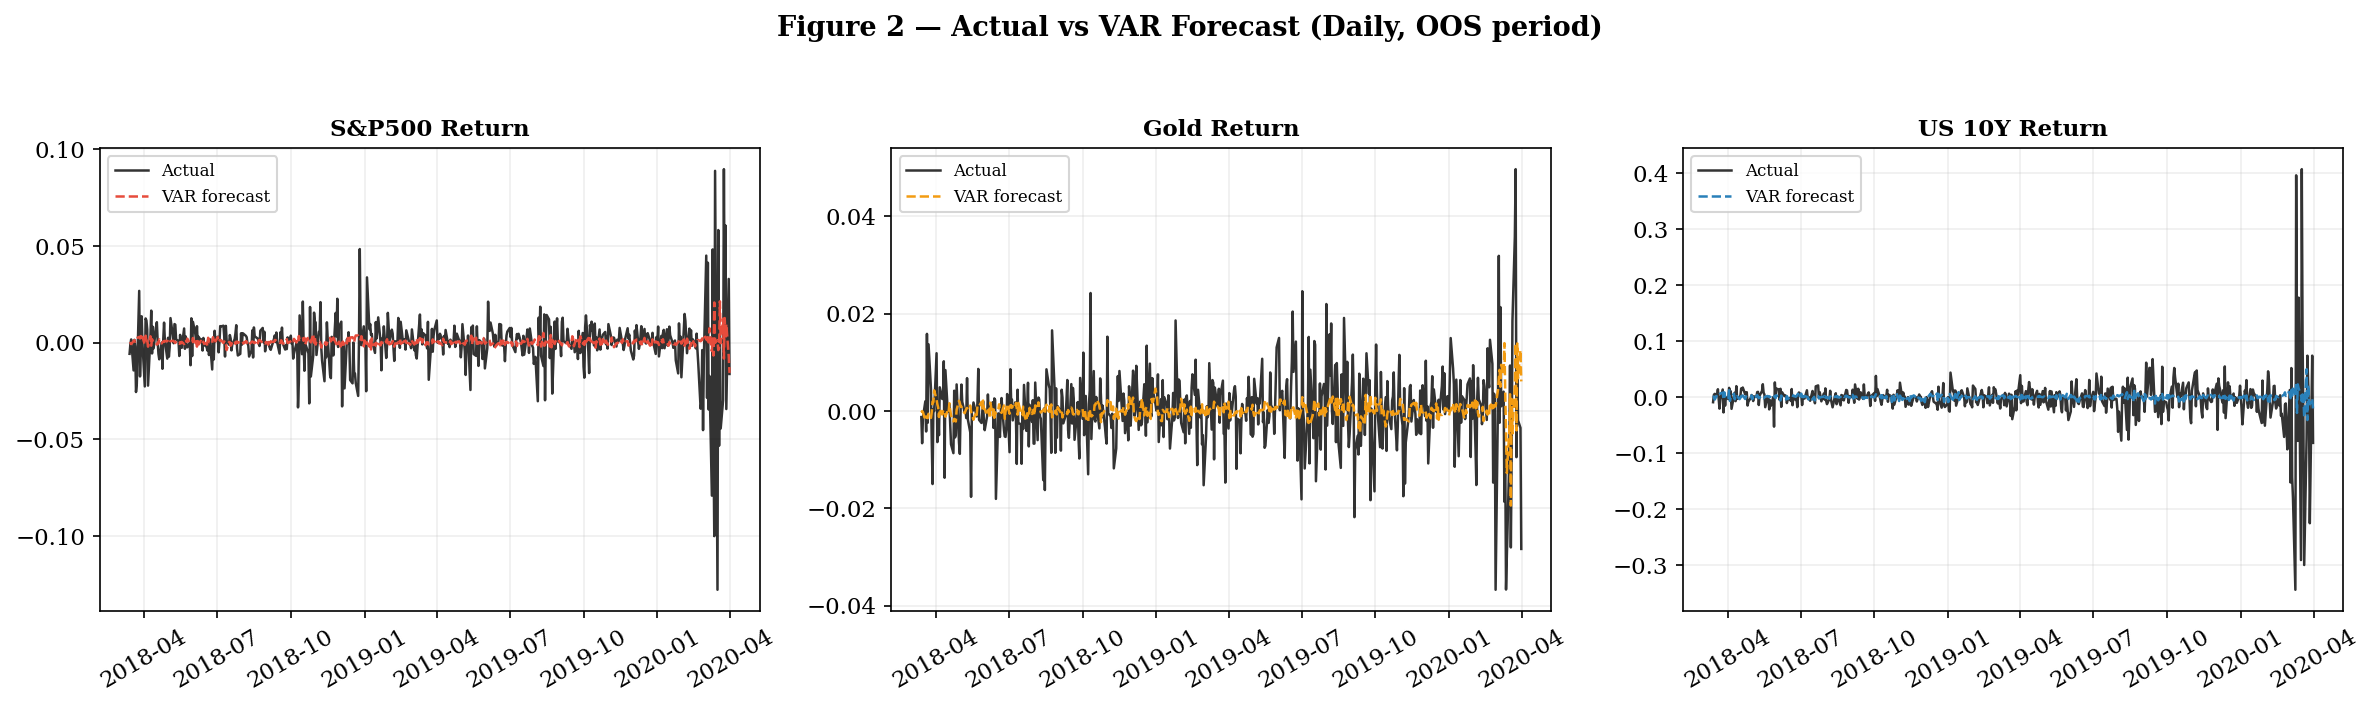

In [12]:
plot_targets = {
    'r_sp500': ('S&P500 Return', '#e74c3c'),
    'r_gold':  ('Gold Return', '#f39c12'),
    'r_bond':  ('US 10Y Return', '#2980b9'),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
dates = var_test.index

for ax, (col, (title, color)) in zip(axes, plot_targets.items()):
    actual = var_test[col].values
    pred   = np.array(daily_var_preds[col])

    ax.plot(dates, actual, color='black', linewidth=1.2, label='Actual', alpha=0.8)
    ax.plot(dates, pred, color=color, linewidth=1.2, label='VAR forecast', linestyle='--')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Figure 2 \u2014 Actual vs VAR Forecast (Daily, OOS period)',
             fontweight='bold', fontsize=13, y=1.04)
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig_daily_actual_vs_forecast.png', bbox_inches='tight')
plt.show()


### Daily HAR — Out-of-Sample Forecast

We apply a HAR-style specification to daily **return** forecasting, capturing persistence across three horizons:
- **Daily** component (1-day lag)
- **Weekly** component (5-day rolling average, lagged)
- **Monthly** component (22-day rolling average, lagged)

Each target return is regressed on its own HAR components plus oil return components. This tests whether multi-horizon persistence — which works well for volatility (Part 2) — also improves return forecasting relative to the VAR system.

In [13]:
har_ret_targets = {'r_sp500': 'S&P500', 'r_gold': 'Gold', 'r_bond': 'US 10Y'}

for col in list(har_ret_targets.keys()) + ['r_oil']:
    df[f'{col}_lag1']  = df[col].shift(1)
    df[f'{col}_avg5']  = df[col].rolling(5).mean().shift(1)
    df[f'{col}_avg22'] = df[col].rolling(22).mean().shift(1)


har_feat_all = []
for col in har_ret_targets:
    har_feat_all += [f'{col}_lag1', f'{col}_avg5', f'{col}_avg22']
har_feat_all += ['r_oil_lag1', 'r_oil_avg5', 'r_oil_avg22']

har_ret_df = df[list(har_ret_targets.keys()) + har_feat_all].dropna()

split_har = int(len(har_ret_df) * 0.8)
har_train = har_ret_df.iloc[:split_har]
har_test  = har_ret_df.iloc[split_har:]

print(f"HAR return train: {har_train.index[0].date()} to {har_train.index[-1].date()} ({len(har_train)} obs)")
print(f"HAR return test:  {har_test.index[0].date()} to {har_test.index[-1].date()} ({len(har_test)} obs)\n")


har_ret_preds = {}
print("Daily HAR Return — OOS forecast performance:")
print(f"{'Variable':<12} {'RMSE':>10} {'MAE':>10} {'OOS R²':>10}")
print("-" * 45)

for col, label in har_ret_targets.items():
    
    x_cols = [f'{col}_lag1', f'{col}_avg5', f'{col}_avg22',
              'r_oil_lag1', 'r_oil_avg5', 'r_oil_avg22']
    X_tr = sm.add_constant(har_train[x_cols])
    X_te = sm.add_constant(har_test[x_cols])
    mdl = sm.OLS(har_train[col], X_tr).fit()
    pred = mdl.predict(X_te)
    har_ret_preds[col] = pred.values

    actual = har_test[col].values
    rmse, mae, r2 = oos_metrics(actual, pred.values)
    print(f"{label:<12} {rmse:>10.6f} {mae:>10.6f} {r2:>10.4f}")

HAR return train: 2010-02-03 to 2018-03-20 (2120 obs)
HAR return test:  2018-03-21 to 2020-03-31 (530 obs)

Daily HAR Return — OOS forecast performance:
Variable           RMSE        MAE     OOS R²
---------------------------------------------
S&P500         0.014886   0.008078     0.0080
Gold           0.008134   0.005602    -0.0114
US 10Y         0.043659   0.019502     0.0046


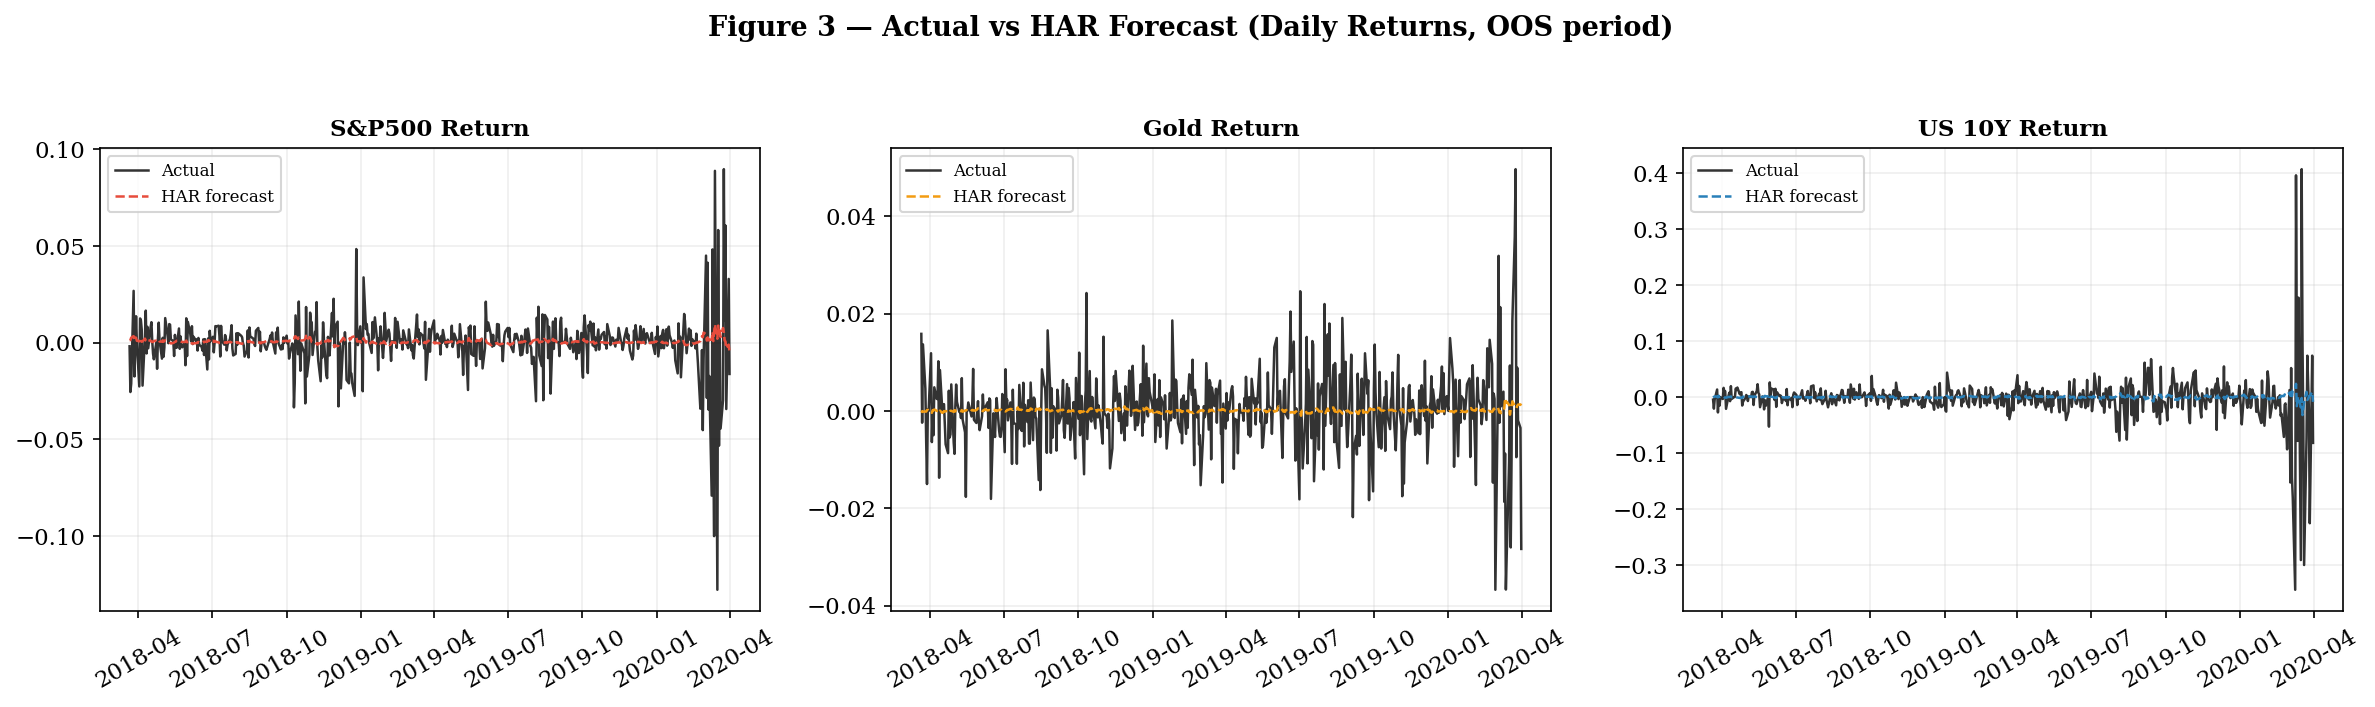

In [14]:
# --- Actual vs HAR forecast plot (daily, OOS period) ---
plot_targets_har = {
    'r_sp500': ('S&P500 Return', '#e74c3c'),
    'r_gold':  ('Gold Return', '#f39c12'),
    'r_bond':  ('US 10Y Return', '#2980b9'),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
dates_har = har_test.index

for ax, (col, (title, color)) in zip(axes, plot_targets_har.items()):
    actual = har_test[col].values
    pred   = har_ret_preds[col]

    ax.plot(dates_har, actual, color='black', linewidth=1.2, label='Actual', alpha=0.8)
    ax.plot(dates_har, pred, color=color, linewidth=1.2, label='HAR forecast', linestyle='--')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Figure 3 \u2014 Actual vs HAR Forecast (Daily Returns, OOS period)',
             fontweight='bold', fontsize=13, y=1.04)
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig_daily_actual_vs_har_forecast.png', bbox_inches='tight')
plt.show()

---
## Part 4 — Monthly Macro Analysis

We now investigate whether oil price shocks transmit to macroeconomic activity. We use actual monthly macro data from `monthly_clean.csv` (not resampled daily data).

**Variables:**
- Industrial Production growth (month-over-month)
- Manufacturing ISM change
- US Retail Sales growth

**Approach:**
1. Check stationarity of each series (ADF + KPSS)
2. Test for cointegration (Johansen) — if supported, estimate VECM; otherwise stay in differences
3. Estimate macro VAR system with oil
4. Granger causality, IRFs, and FEVD
5. Compare forecasts: naive vs AR(1) vs VAR

In [15]:
macro = pd.read_csv("../Data/interim/monthly_clean.csv", parse_dates=["Date"]).set_index("Date")

# reload full daily data (not truncated) to compute monthly oil returns over the entire sample
daily_full = pd.read_csv("../Data/interim/daily_clean.csv", parse_dates=["Date"]).set_index("Date")
daily_full['r_oil_full'] = np.log(daily_full['Brent futures'] / daily_full['Brent futures'].shift(1))

oil_monthly = daily_full['r_oil_full'].resample('ME').sum().rename('r_oil_m')
oil_pos_monthly = oil_monthly.clip(lower=0).rename('r_oil_pos_m')

macro = macro.join(oil_monthly).join(oil_pos_monthly)

macro['ip_growth']     = macro['Industrial production'].pct_change() * 100
macro['retail_growth'] = macro['US Retail Sales'].pct_change() * 100
macro['ism_chg']       = macro['Manufacturing ISM'].diff()

cols_needed = ['ip_growth', 'retail_growth', 'ism_chg', 'r_oil_pos_m']
macro = macro.dropna(subset=cols_needed).replace([np.inf, -np.inf], np.nan).dropna(subset=cols_needed)

print(f"Monthly macro sample: {macro.index[0].date()} to {macro.index[-1].date()}, {len(macro)} obs")
print(f"\nFirst few rows:")
macro[cols_needed].head()

Monthly macro sample: 1997-01-31 to 2026-01-31, 349 obs

First few rows:


,ip_growth,retail_growth,ism_chg,r_oil_pos_m
Date,,,,
1997-01-31,0.158513,0.621754,-1.4,0.000000
1997-02-28,1.193852,0.334807,-0.7,0.000000
1997-03-31,0.634613,-0.595488,0.7,0.045152
1997-04-30,0.117220,-0.564358,-0.1,0.000000
1997-05-31,0.553965,1.659379,2.4,0.044592


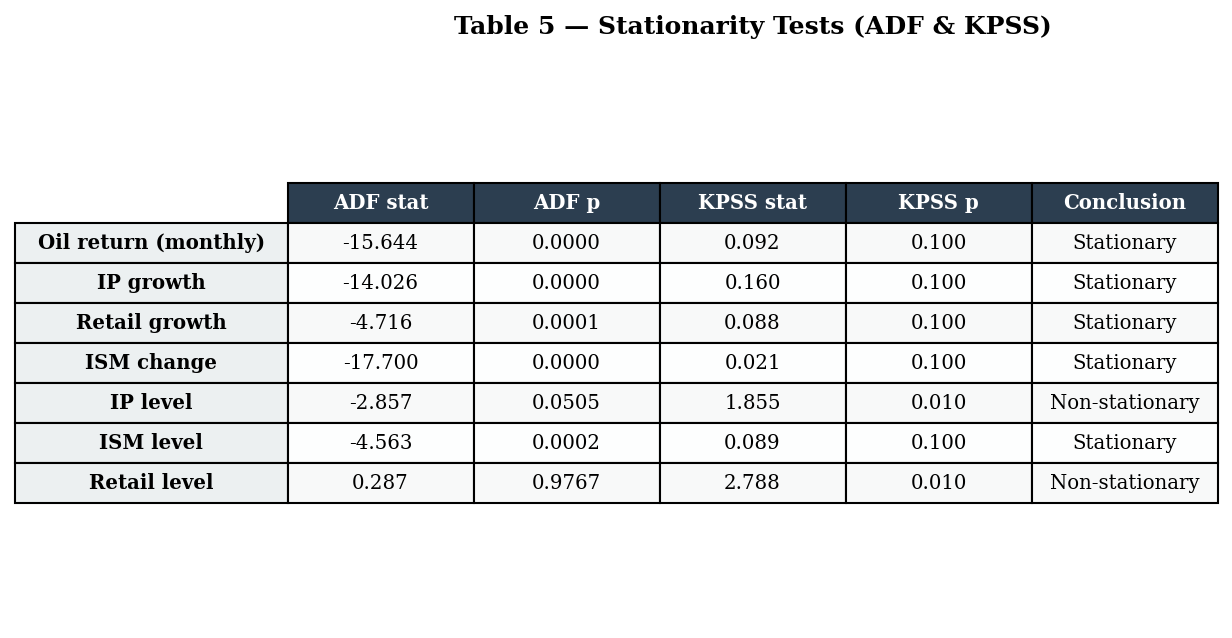


Key takeaway:
- Growth rates and changes are stationary → safe for VAR in levels (of transformed data)
- Levels (IP, ISM, Retail) are non-stationary → we should not use them directly in VAR


In [16]:
# --- A. Stationarity diagnostics: ADF and KPSS ---
# ADF: H0 = unit root (non-stationary). KPSS: H0 = stationary.
# If ADF rejects and KPSS does not reject → stationary (good for VAR in levels)
# If ADF does not reject and KPSS rejects → non-stationary (need differencing or VECM)

stationarity_rows = []
test_series = {
    "Oil return (monthly)": macro['r_oil_m'],
    "IP growth": macro['ip_growth'],
    "Retail growth": macro['retail_growth'],
    "ISM change": macro['ism_chg'],
    "IP level": macro['Industrial production'],
    "ISM level": macro['Manufacturing ISM'],
    "Retail level": macro['US Retail Sales'],
}

for name, series in test_series.items():
    s = series.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(s, maxlag=12, autolag='AIC')
    kpss_stat, kpss_p, _, _ = kpss(s, regression='c', nlags='auto')

    stationarity_rows.append({
        "Series": name,
        "ADF stat": f"{adf_stat:.3f}",
        "ADF p": f"{adf_p:.4f}",
        "KPSS stat": f"{kpss_stat:.3f}",
        "KPSS p": f"{kpss_p:.3f}",
        "Conclusion": "Stationary" if (adf_p < 0.05 and kpss_p > 0.05)
                      else "Non-stationary" if (adf_p > 0.05 and kpss_p < 0.05)
                      else "Ambiguous"
    })

stat_df = pd.DataFrame(stationarity_rows).set_index("Series")
show_table(stat_df, "Table 5 — Stationarity Tests (ADF & KPSS)", "table5_stationarity.png")

print("\nKey takeaway:")
print("- Growth rates and changes are stationary → safe for VAR in levels (of transformed data)")
print("- Levels (IP, ISM, Retail) are non-stationary → we should not use them directly in VAR")

### B. Cointegration check (Johansen test)

Since the level series (IP, ISM, Retail) are non-stationary, we test whether they share a long-run equilibrium with oil prices. If cointegration exists, we should use VECM instead of a plain VAR in differences.

In [17]:
# cumulative oil return as a "price level" proxy
macro['oil_cum'] = macro['r_oil_m'].cumsum()

level_data = macro[['oil_cum', 'Industrial production', 'Manufacturing ISM', 'US Retail Sales']].dropna()

# Johansen test with 2 lags, constant inside the cointegrating relation
johansen = coint_johansen(level_data, det_order=0, k_ar_diff=2)

print("Johansen Cointegration Test")
print("="*60)
var_names = ['Oil (cum)', 'IP', 'ISM', 'Retail']

# Trace test
print("\nTrace test (H0: rank <= r):")
print(f"{'Rank':<8} {'Trace stat':<14} {'5% CV':<12} {'Reject H0?'}")
print("-" * 50)
for i in range(len(johansen.trace_stat)):
    reject = 'Yes' if johansen.trace_stat[i] > johansen.trace_stat_crit_vals[i, 1] else 'No'
    print(f"r <= {i:<4} {johansen.trace_stat[i]:<14.3f} {johansen.trace_stat_crit_vals[i,1]:<12.3f} {reject}")

# Max-eigenvalue test
print("\nMax-eigenvalue test (H0: rank = r vs rank = r+1):")
print(f"{'Rank':<8} {'Max-eigen':<14} {'5% CV':<12} {'Reject H0?'}")
print("-" * 50)
for i in range(len(johansen.max_eig_stat)):
    reject = 'Yes' if johansen.max_eig_stat[i] > johansen.max_eig_stat_crit_vals[i, 1] else 'No'
    print(f"r = {i:<5} {johansen.max_eig_stat[i]:<14.3f} {johansen.max_eig_stat_crit_vals[i,1]:<12.3f} {reject}")

# Count cointegrating vectors (use trace test)
n_coint_trace = sum(1 for i in range(len(johansen.trace_stat))
                    if johansen.trace_stat[i] > johansen.trace_stat_crit_vals[i, 1])
n_coint_eigen = sum(1 for i in range(len(johansen.max_eig_stat))
                    if johansen.max_eig_stat[i] > johansen.max_eig_stat_crit_vals[i, 1])

# Conservative: use the minimum of trace and eigenvalue tests
n_coint = min(n_coint_trace, n_coint_eigen)
use_vecm = n_coint > 0

print(f"\nCointegrating relations: {n_coint_trace} (trace), {n_coint_eigen} (max-eigen)")
print(f"Conservative estimate: {n_coint}")
if use_vecm:
    print("-> Cointegration detected. We estimate both VAR in differences AND VECM for comparison.")
else:
    print("-> No cointegration detected. We proceed with VAR on stationary transformations only.")


Johansen Cointegration Test

Trace test (H0: rank <= r):
Rank     Trace stat     5% CV        Reject H0?
--------------------------------------------------
r <= 0    65.762         47.855       Yes
r <= 1    24.364         29.796       No
r <= 2    6.535          15.494       No
r <= 3    0.361          3.841        No

Max-eigenvalue test (H0: rank = r vs rank = r+1):
Rank     Max-eigen      5% CV        Reject H0?
--------------------------------------------------
r = 0     41.398         27.586       Yes
r = 1     17.829         21.131       No
r = 2     6.174          14.264       No
r = 3     0.361          3.841        No

Cointegrating relations: 1 (trace), 1 (max-eigen)
Conservative estimate: 1
-> Cointegration detected. We estimate both VAR in differences AND VECM for comparison.


### C. Macro VAR — oil return + IP growth + ISM change + retail growth

We estimate a VAR on the stationary transformations. Oil is ordered first so that it acts as the "shock source" in the Cholesky decomposition. This is economically motivated: oil is an exogenous commodity price, while macro variables respond to it with a lag.

Macro VAR — lag order selection:
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -2.667      -2.623     0.06943      -2.650
1      -3.363     -3.139*     0.03463     -3.274*
2     -3.404*      -3.001    0.03324*      -3.244
3      -3.383      -2.801     0.03394      -3.151
4      -3.363      -2.602     0.03466      -3.060
5      -3.364      -2.425     0.03460      -2.990
6      -3.351      -2.232     0.03509      -2.905
-------------------------------------------------

Selected lag (AIC): 2
Macro VAR(2) — 347 observations
AIC = -3.42, BIC = -3.02


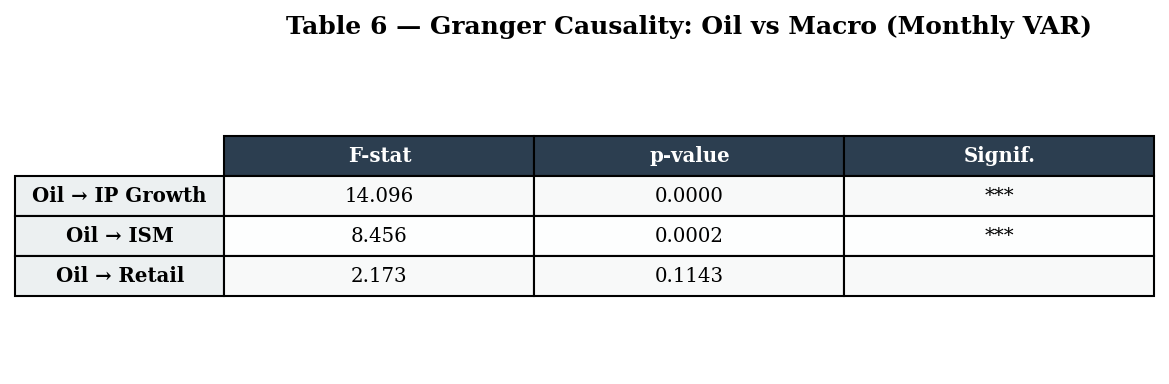

In [18]:
macro_var_cols = ['r_oil_m', 'ip_growth', 'ism_chg', 'retail_growth']
macro_var_data = macro[macro_var_cols].dropna()

macro_var_model = VAR(macro_var_data)
macro_lag_sel = macro_var_model.select_order(maxlags=6)
print("Macro VAR — lag order selection:")
print(macro_lag_sel.summary())

macro_best = macro_lag_sel.aic
print(f"\nSelected lag (AIC): {macro_best}")

macro_var_fit = macro_var_model.fit(macro_best)
print(f"Macro VAR({macro_best}) — {macro_var_fit.nobs} observations")
print(f"AIC = {macro_var_fit.aic:.2f}, BIC = {macro_var_fit.bic:.2f}")

# --- Granger causality ---
gc_macro_rows = []
for caused, label in [('ip_growth', 'Oil → IP Growth'),
                       ('ism_chg', 'Oil → ISM'),
                       ('retail_growth', 'Oil → Retail')]:
    t = macro_var_fit.test_causality(caused, ['r_oil_m'], kind='f')
    gc_macro_rows.append({
        "Direction": label,
        "F-stat": f"{t.test_statistic:.3f}",
        "p-value": f"{t.pvalue:.4f}",
        "Signif.": "***" if t.pvalue < 0.01 else "**" if t.pvalue < 0.05 else "*" if t.pvalue < 0.1 else ""
    })


gc_macro_df = pd.DataFrame(gc_macro_rows).set_index("Direction")
show_table(gc_macro_df, "Table 6 — Granger Causality: Oil vs Macro (Monthly VAR)", "table6_granger_macro.png")

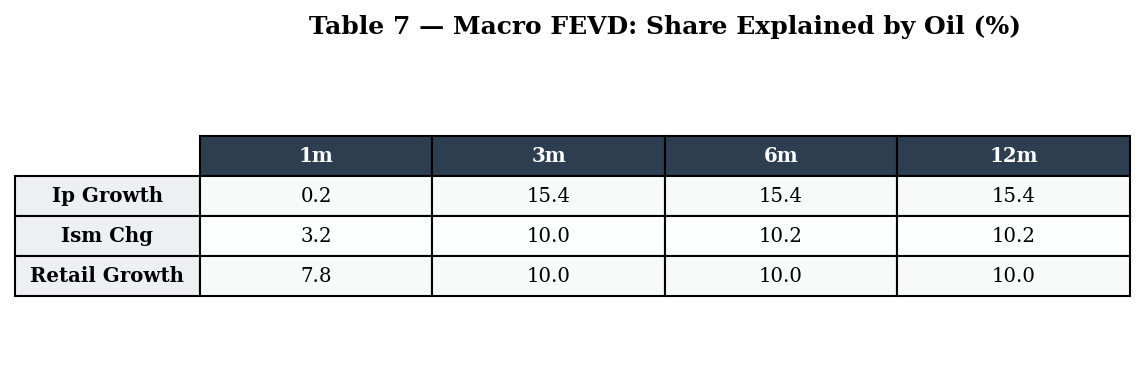

In [19]:
# --- Macro FEVD ---
fevd_macro = macro_var_fit.fevd(12)
oil_m_idx = macro_var_cols.index('r_oil_m')

horizons_m = [1, 3, 6, 12]
fevd_m_rows = []
for h in horizons_m:
    for i, resp in enumerate(macro_var_cols):
        if resp == 'r_oil_m':
            continue
        oil_share = fevd_macro.decomp[i, h-1, oil_m_idx]
        own_share = fevd_macro.decomp[i, h-1, i]
        fevd_m_rows.append({
            "Variable": resp.replace('_', ' ').title(),
            "Horizon": f"{h}m",
            "Oil (%)": f"{oil_share*100:.1f}",
            "Own (%)": f"{own_share*100:.1f}",
        })

fevd_m_df = pd.DataFrame(fevd_m_rows)
fevd_m_pivot = fevd_m_df.pivot(index="Variable", columns="Horizon", values="Oil (%)")
fevd_m_pivot = fevd_m_pivot[['1m', '3m', '6m', '12m']]
show_table(fevd_m_pivot, "Table 7 — Macro FEVD: Share Explained by Oil (%)", "table7_fevd_macro.png")

### D. VECM (if cointegration was detected)

If the Johansen test found cointegrating relations, we estimate a Vector Error Correction Model on the level series. VECM accounts for both short-run dynamics and long-run equilibrium adjustment.

If no cointegration was found, we skip VECM and note that the VAR in stationary transformations is the appropriate specification.

In [20]:
if use_vecm:
    print(f"Cointegration detected ({n_coint} relation(s)). Estimating VECM...\n")

    vecm_data = level_data.copy()
    coint_rank = min(n_coint, 2)
    vecm_model = VECM(vecm_data, k_ar_diff=2, coint_rank=coint_rank, deterministic='ci')
    vecm_fit = vecm_model.fit()

    print("VECM estimation results:")
    print(f"  Cointegrating rank: {coint_rank}")
    print(f"  Lag differences: 2")
    print(f"  Observations: {vecm_fit.nobs}")

    var_labels = ['Oil (cum)', 'IP', 'ISM', 'Retail']

    # Beta
    beta_df = pd.DataFrame(
        vecm_fit.beta,
        index=var_labels,
        columns=[f'CV{i+1}' for i in range(vecm_fit.beta.shape[1])]
    ).round(4)
    print("\nBeta (cointegrating vectors) - long-run equilibrium relationships:")
    print(beta_df.to_string())
    print("\nEach column is a cointegrating vector. The linear combination beta'*X_t is stationary.")

    # Alpha
    alpha_df = pd.DataFrame(
        vecm_fit.alpha,
        index=var_labels,
        columns=[f'EC{i+1}' for i in range(vecm_fit.alpha.shape[1])]
    ).round(4)
    print("\nAlpha (error-correction / adjustment speeds):")
    print(alpha_df.to_string())
    print("\nInterpretation:")
    print("- Negative alpha = variable corrects back toward equilibrium when displaced above it.")
    print("- Large |alpha| = fast adjustment; near-zero alpha = variable is weakly exogenous.")
    for i, var in enumerate(var_labels):
        a = vecm_fit.alpha[i, 0]
        if abs(a) < 0.01:
            print(f"  {var}: alpha={a:.4f} -> weakly exogenous (does not adjust to disequilibrium)")
        elif a < 0:
            print(f"  {var}: alpha={a:.4f} -> corrects downward when above equilibrium (half-life ~ {abs(0.693/a):.1f} periods)")
        else:
            print(f"  {var}: alpha={a:.4f} -> moves further from equilibrium (potential overshooting)")

else:
    print("No cointegration detected by Johansen test (conservative: min of trace and max-eigenvalue).")
    print("We stay with the VAR on stationary transformations (growth rates / changes).")
    print("This is the standard approach when macro variables are I(1) but not cointegrated.")


Cointegration detected (1 relation(s)). Estimating VECM...

VECM estimation results:
  Cointegrating rank: 1
  Lag differences: 2
  Observations: 346

Beta (cointegrating vectors) - long-run equilibrium relationships:
              CV1
Oil (cum)  1.0000
IP         0.4454
ISM       -3.1126
Retail    -0.0000

Each column is a cointegrating vector. The linear combination beta'*X_t is stationary.

Alpha (error-correction / adjustment speeds):
               EC1
Oil (cum)  -0.0006
IP         -0.0066
ISM         0.0290
Retail    -73.8984

Interpretation:
- Negative alpha = variable corrects back toward equilibrium when displaced above it.
- Large |alpha| = fast adjustment; near-zero alpha = variable is weakly exogenous.
  Oil (cum): alpha=-0.0006 -> weakly exogenous (does not adjust to disequilibrium)
  IP: alpha=-0.0066 -> weakly exogenous (does not adjust to disequilibrium)
  ISM: alpha=0.0290 -> moves further from equilibrium (potential overshooting)
  Retail: alpha=-73.8984 -> corrects d

### E. Macro Forecast Comparison

We compare five approaches for predicting macro variables out-of-sample (80/20 split):
1. **Naïve** (random walk): forecast = last observed value
2. **AR(1)**: own lag only
3. **AR(1) + Oil**: own lag + lagged positive oil return
4. **HAR**: adapted Heterogeneous Autoregressive model — uses 1-month, 3-month, and 6-month average lags to capture multi-horizon persistence in macro dynamics
5. **HAR + Oil**: HAR components plus lagged oil volatility
6. **VAR**: the full macro VAR system including oil

This tells us whether oil and multi-horizon persistence add forecasting information beyond each variable's own history.


Train: 1997-07-31 to 2020-04-30 (274 obs)
Test:  2020-05-31 to 2026-01-31 (69 obs)


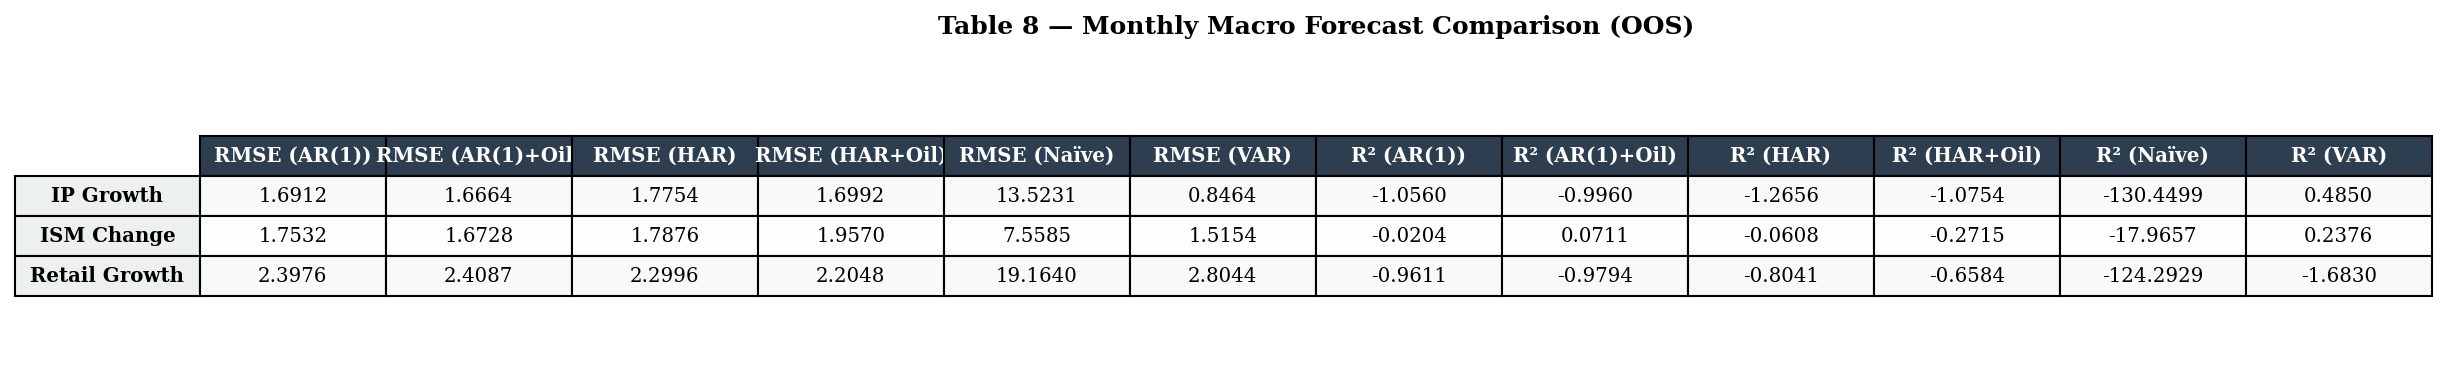

In [21]:
for col in ['ip_growth', 'retail_growth', 'ism_chg']:
    macro[f'{col}_lag'] = macro[col].shift(1)
macro['r_oil_pos_lag'] = macro['r_oil_pos_m'].shift(1)

# --- HAR components for monthly data ---
for col in ['ip_growth', 'retail_growth', 'ism_chg']:
    macro[f'{col}_h1'] = macro[col].shift(1)                        # 1-month lag
    macro[f'{col}_h3'] = macro[col].rolling(3).mean().shift(1)      # 3-month avg
    macro[f'{col}_h6'] = macro[col].rolling(6).mean().shift(1)      # 6-month avg

# oil volatility component for HAR+oil
macro['oil_vol_m'] = macro['r_oil_m'].abs()
macro['oil_vol_m_lag'] = macro['oil_vol_m'].shift(1)
macro['oil_vol_m_h3'] = macro['oil_vol_m'].rolling(3).mean().shift(1)

macro_clean = macro.dropna(subset=['ip_growth_lag', 'retail_growth_lag', 'ism_chg_lag',
                                    'r_oil_pos_lag',
                                    'ip_growth_h6', 'retail_growth_h6', 'ism_chg_h6',
                                    'oil_vol_m_h3']).copy()

split_m = int(len(macro_clean) * 0.8)
train_m = macro_clean.iloc[:split_m]
test_m  = macro_clean.iloc[split_m:]

print(f"Train: {train_m.index[0].date()} to {train_m.index[-1].date()} ({len(train_m)} obs)")
print(f"Test:  {test_m.index[0].date()} to {test_m.index[-1].date()} ({len(test_m)} obs)")

macro_targets = {
    "IP Growth": "ip_growth",
    "ISM Change": "ism_chg",
    "Retail Growth": "retail_growth",
}

forecast_rows = []
har_preds = {}

for name, y in macro_targets.items():
    lag = f"{y}_lag"
    actual = test_m[y].values

    # 1. Naive
    naive_pred = np.full(len(test_m), train_m[y].iloc[-1])
    rmse_n, mae_n, r2_n = oos_metrics(actual, naive_pred)
    forecast_rows.append({"Target": name, "Model": "Na\u00efve",
                          "RMSE": f"{rmse_n:.4f}", "MAE": f"{mae_n:.4f}", "R\u00b2": f"{r2_n:.4f}"})

    # 2. AR(1)
    (rmse_ar, mae_ar, r2_ar), _ = run_ols(train_m, test_m, y, [lag])
    forecast_rows.append({"Target": name, "Model": "AR(1)",
                          "RMSE": f"{rmse_ar:.4f}", "MAE": f"{mae_ar:.4f}", "R\u00b2": f"{r2_ar:.4f}"})

    # 3. AR(1) + oil
    (rmse_oil, mae_oil, r2_oil), _ = run_ols(train_m, test_m, y, [lag, 'r_oil_pos_lag'])
    forecast_rows.append({"Target": name, "Model": "AR(1)+Oil",
                          "RMSE": f"{rmse_oil:.4f}", "MAE": f"{mae_oil:.4f}", "R\u00b2": f"{r2_oil:.4f}"})

    # 4. HAR (1m + 3m avg + 6m avg)
    har_cols = [f'{y}_h1', f'{y}_h3', f'{y}_h6']
    (rmse_h, mae_h, r2_h), mdl_har = run_ols(train_m, test_m, y, har_cols)
    forecast_rows.append({"Target": name, "Model": "HAR",
                          "RMSE": f"{rmse_h:.4f}", "MAE": f"{mae_h:.4f}", "R\u00b2": f"{r2_h:.4f}"})

    # 5. HAR + oil volatility
    har_oil_cols = [f'{y}_h1', f'{y}_h3', f'{y}_h6', 'oil_vol_m_lag', 'oil_vol_m_h3']
    (rmse_ho, mae_ho, r2_ho), mdl_har_oil = run_ols(train_m, test_m, y, har_oil_cols)
    forecast_rows.append({"Target": name, "Model": "HAR+Oil",
                          "RMSE": f"{rmse_ho:.4f}", "MAE": f"{mae_ho:.4f}", "R\u00b2": f"{r2_ho:.4f}"})

    
    X_te_har = sm.add_constant(test_m[har_cols])
    har_preds[y] = mdl_har.predict(X_te_har)

# 6. VAR forecasts
var_forecast_data = macro_clean[macro_var_cols].copy()
var_train = var_forecast_data.iloc[:split_m]
var_test  = var_forecast_data.iloc[split_m:]

var_m_train = VAR(var_train)
var_m_fit = var_m_train.fit(macro_best)

var_preds = {col: [] for col in macro_var_cols if col != 'r_oil_m'}
for i in range(len(var_test)):
    history = var_forecast_data.iloc[:split_m + i].values
    fc = var_m_fit.forecast(history[-macro_best:], steps=1)
    for j, col in enumerate(macro_var_cols):
        if col != 'r_oil_m':
            var_preds[col].append(fc[0, j])

for name, y in macro_targets.items():
    actual = test_m[y].values
    pred_var = np.array(var_preds[y])
    rmse_v, mae_v, r2_v = oos_metrics(actual, pred_var)
    forecast_rows.append({"Target": name, "Model": "VAR",
                          "RMSE": f"{rmse_v:.4f}", "MAE": f"{mae_v:.4f}", "R\u00b2": f"{r2_v:.4f}"})

fc_df = pd.DataFrame(forecast_rows)
fc_pivot = fc_df.pivot(index="Target", columns="Model", values=["RMSE", "R\u00b2"])
fc_pivot.columns = [f"{v} ({m})" for v, m in fc_pivot.columns]
show_table(fc_pivot, "Table 8 \u2014 Monthly Macro Forecast Comparison (OOS)", "table8_macro_forecast.png")


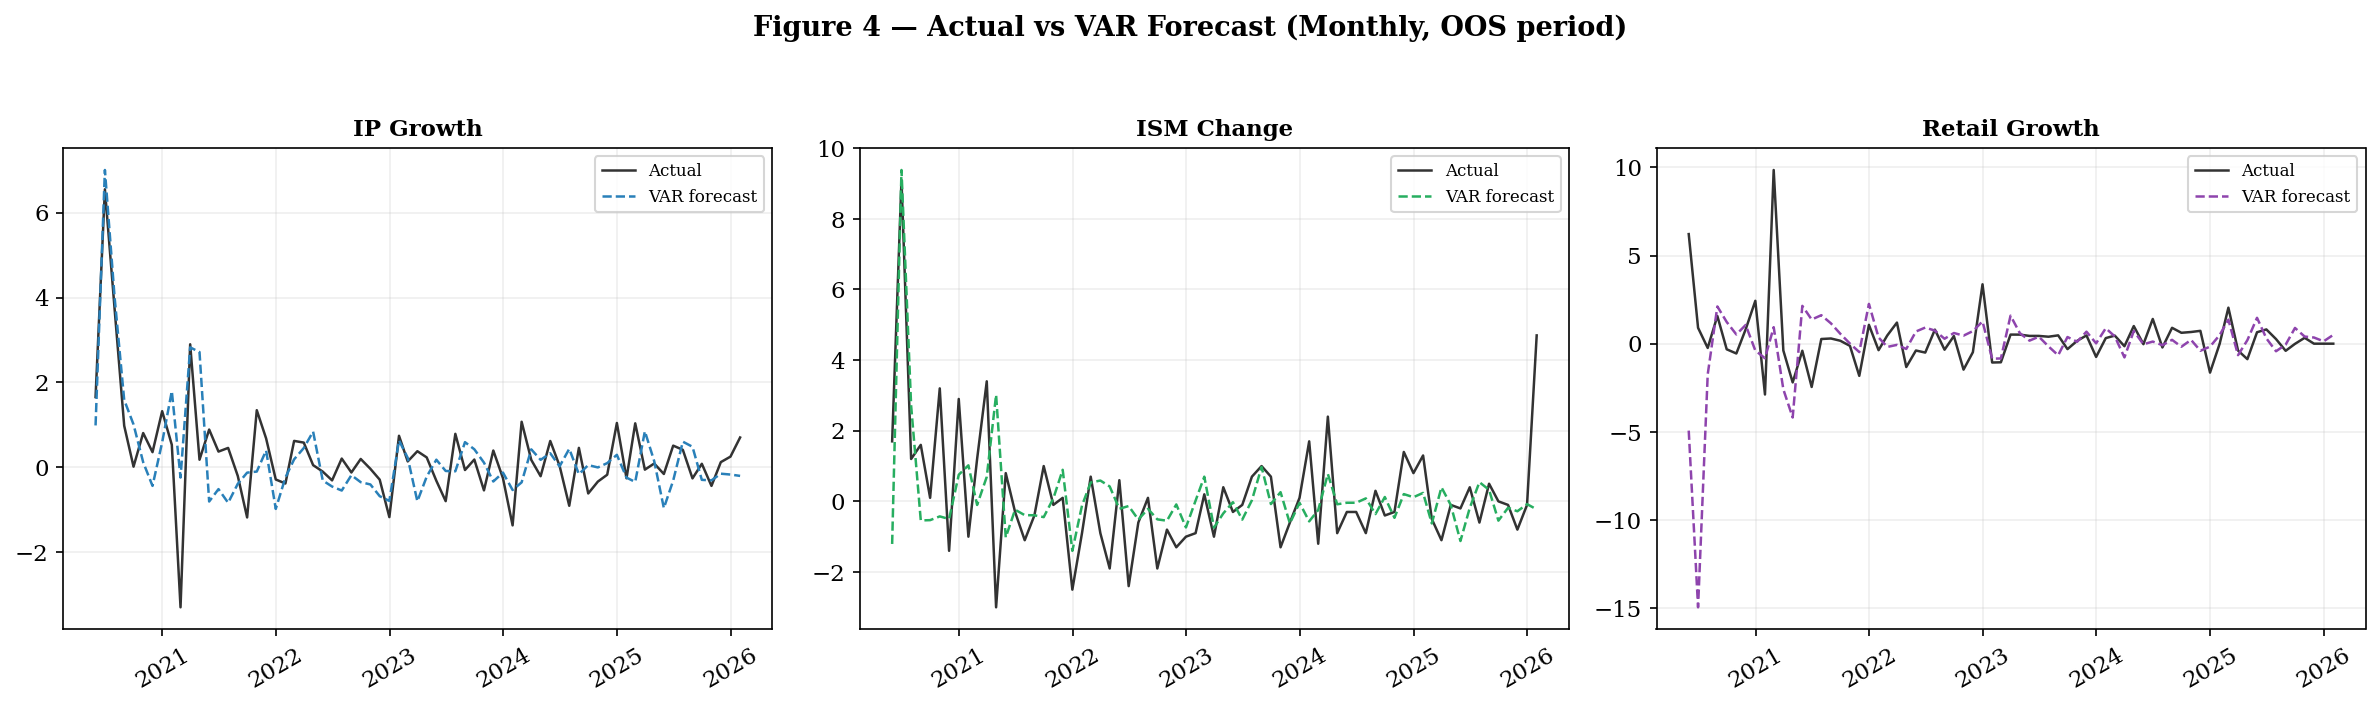

In [22]:
# --- Actual vs VAR forecast plot for key macro variables ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, y), color in zip(axes, macro_targets.items(),
                                  ['#2980b9', '#27ae60', '#8e44ad']):
    actual = test_m[y].values
    pred = np.array(var_preds[y])
    dates = test_m.index

    ax.plot(dates, actual, color='black', linewidth=1.2, label='Actual', alpha=0.8)
    ax.plot(dates, pred, color=color, linewidth=1.2, label='VAR forecast', linestyle='--')
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle("Figure 4 — Actual vs VAR Forecast (Monthly, OOS period)",
             fontweight='bold', fontsize=13, y=1.04)
plt.tight_layout()
fig.savefig(f"{FIG_DIR}/fig4_actual_vs_forecast.png", bbox_inches='tight')
plt.show()

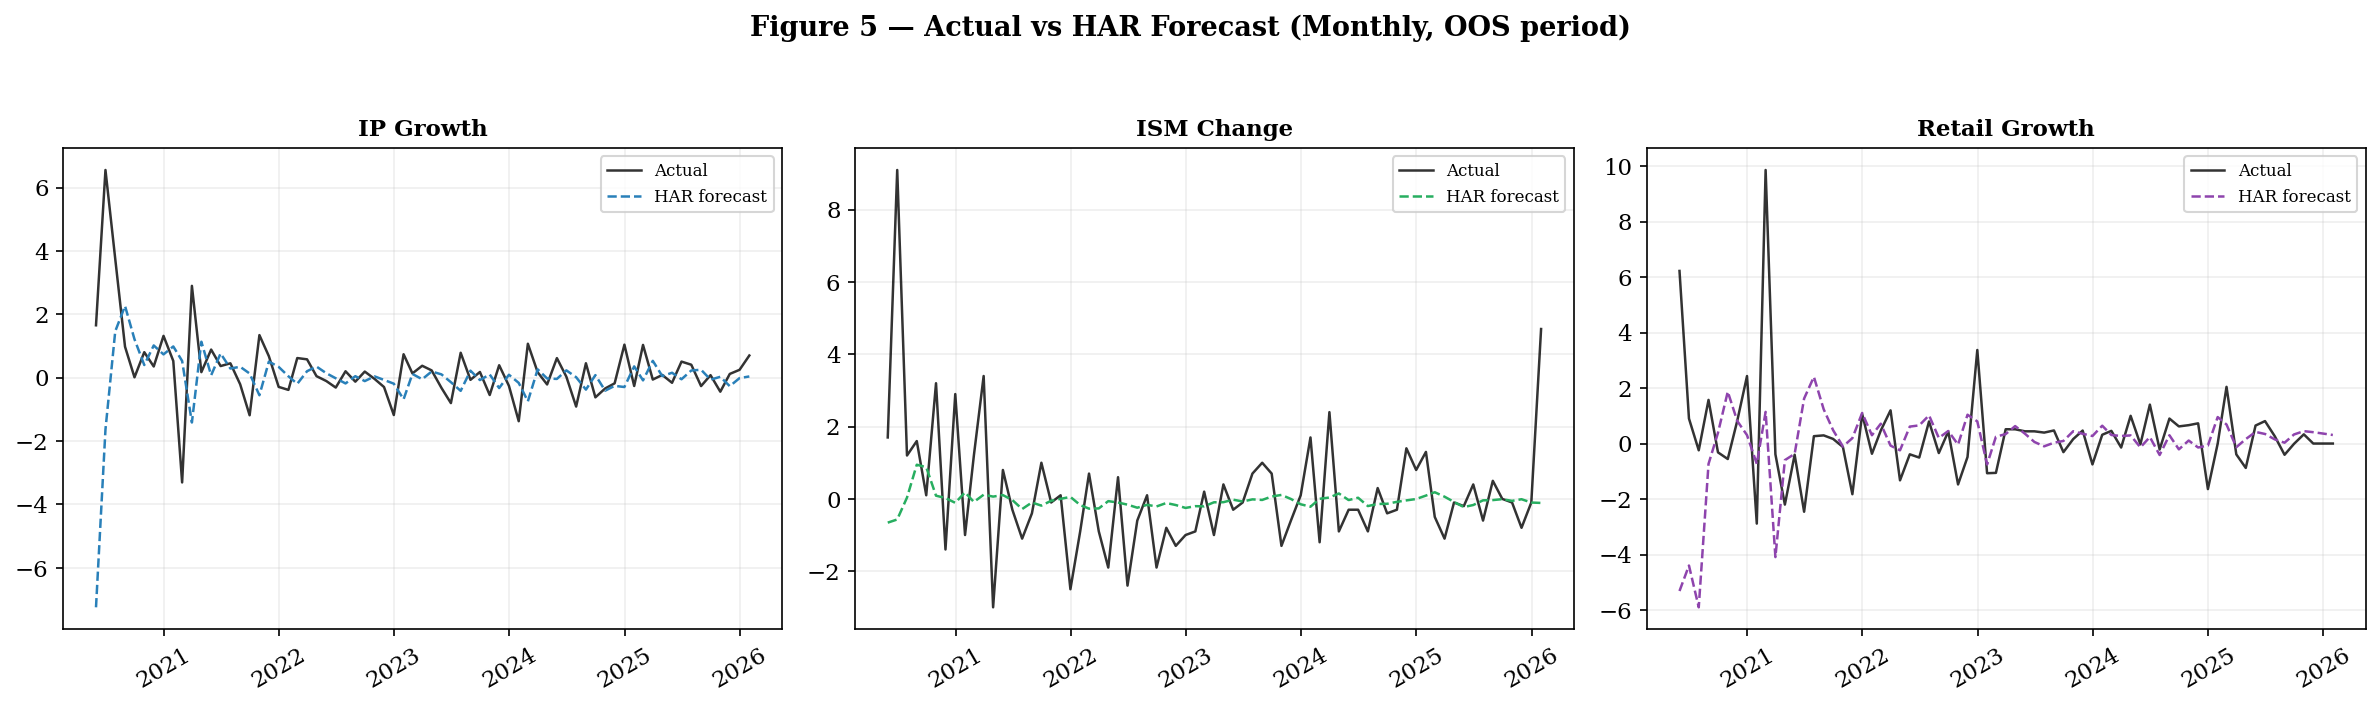

In [23]:
# --- Actual vs HAR forecast plot for key macro variables ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, y), color in zip(axes, macro_targets.items(),
                                  ['#2980b9', '#27ae60', '#8e44ad']):
    actual = test_m[y].values
    pred = np.array(har_preds[y])
    dates = test_m.index

    ax.plot(dates, actual, color='black', linewidth=1.2, label='Actual', alpha=0.8)
    ax.plot(dates, pred, color=color, linewidth=1.2, label='HAR forecast', linestyle='--')
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Figure 5 \u2014 Actual vs HAR Forecast (Monthly, OOS period)',
             fontweight='bold', fontsize=13, y=1.04)
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig5_har_macro_forecast.png', bbox_inches='tight')
plt.show()


---
## Part 5 — Quarterly GDP Analysis

We extend the analysis to the real economy at quarterly frequency. Using GDP and its components, we test whether quarterly oil price shocks — measured as the cumulative daily Brent return within each quarter — have predictive power for GDP growth.

This section mirrors the monthly macro analysis (Part 4) but at a lower frequency where GDP data is available.

In [24]:
# --- Load and prepare quarterly data ---
gdp = pd.read_csv("../Data/processed/quarterly_model.csv", parse_dates=["Date"])
daily_oil = pd.read_csv("../Data/processed/daily_model.csv", parse_dates=["Date"])

# compute daily log-returns for Brent
daily_oil['r_oil_daily'] = np.log(daily_oil['Brent futures'] / daily_oil['Brent futures'].shift(1))

# quarterly aggregation: sum of daily log-returns per quarter
daily_oil['quarter'] = daily_oil['Date'].dt.to_period('Q')
brent_q = daily_oil.groupby('quarter')['r_oil_daily'].sum().reset_index()
brent_q.columns = ['quarter', 'brent_q_ret']

# map GDP dates to quarters
gdp['quarter'] = gdp['Date'].dt.to_period('Q')

# merge
qdf = gdp.merge(brent_q, on='quarter', how='inner').sort_values('quarter').reset_index(drop=True)

# features
qdf['oil_pos'] = qdf['brent_q_ret'].clip(lower=0)
threshold_90 = qdf['brent_q_ret'].quantile(0.90)
qdf['oil_large_shock'] = (qdf['brent_q_ret'] >= threshold_90).astype(int)

# lags
qdf['oil_pos_lag'] = qdf['oil_pos'].shift(1)
qdf['brent_q_ret_lag'] = qdf['brent_q_ret'].shift(1)

gdp_targets = {
    "US GDP": "US GDP_growth",
    "Consumption": "GDP - Personal Consumption_growth",
    "Investment": "GDP - Investment_growth",
}

for name, col in gdp_targets.items():
    qdf[f'{col}_lag'] = qdf[col].shift(1)

qdf_clean = qdf.dropna(subset=['oil_pos_lag'] + [f'{c}_lag' for c in gdp_targets.values()]).copy()

print(f"Quarterly sample: {qdf_clean['quarter'].iloc[0]} to {qdf_clean['quarter'].iloc[-1]}, {len(qdf_clean)} obs")
print(f"90th-percentile oil return threshold: {threshold_90:.4f}")

Quarterly sample: 1990Q2 to 2025Q4, 143 obs
90th-percentile oil return threshold: 0.2072


### Predictive Regressions

We test whether lagged positive oil returns predict next-quarter GDP component growth, controlling for own-lag persistence.

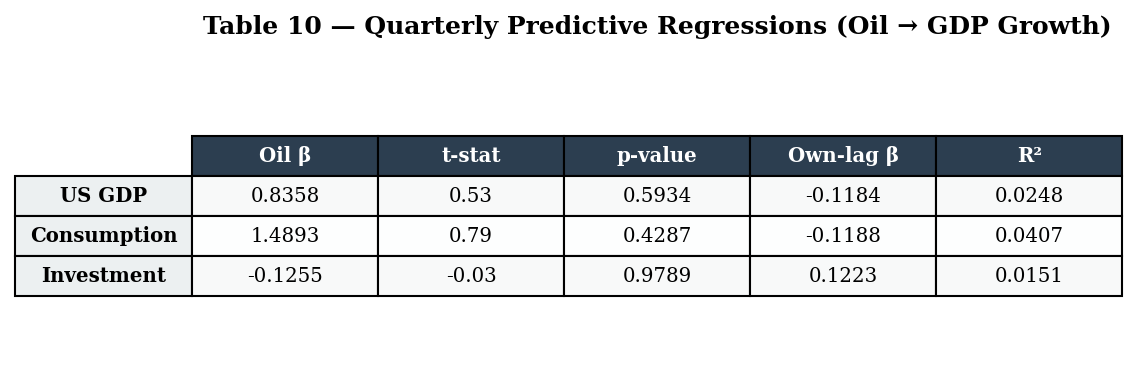

In [25]:
ols_rows = []
for name, y in gdp_targets.items():
    lag = f'{y}_lag'
    X = sm.add_constant(qdf_clean[['oil_pos_lag', lag]])
    mdl = sm.OLS(qdf_clean[y], X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

    oil_beta = mdl.params['oil_pos_lag']
    oil_t = mdl.tvalues['oil_pos_lag']
    oil_p = mdl.pvalues['oil_pos_lag']
    own_beta = mdl.params[lag]

    ols_rows.append({
        "Target": name,
        "Oil β": f"{oil_beta:.4f}",
        "t-stat": f"{oil_t:.2f}",
        "p-value": f"{oil_p:.4f}",
        "Own-lag β": f"{own_beta:.4f}",
        "R²": f"{mdl.rsquared:.4f}",
    })

ols_q = pd.DataFrame(ols_rows).set_index("Target")
show_table(ols_q, "Table 10 — Quarterly Predictive Regressions (Oil → GDP Growth)", "table10_quarterly_ols.png")

### Quarterly VAR and Granger Causality

We estimate a bivariate VAR(p) between quarterly oil returns and each GDP growth component to test Granger causality.

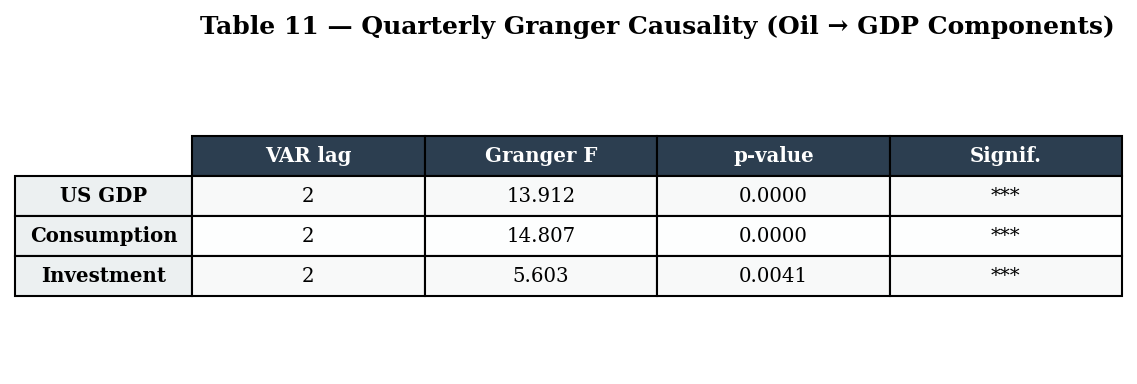

In [26]:
# --- Quarterly VAR + Granger causality ---
gc_q_rows = []

for name, y in gdp_targets.items():
    var_data = qdf_clean[['brent_q_ret', y]].dropna()
    var_mdl = VAR(var_data)

    
    best_bic = np.inf
    best_p = 1
    for p in range(1, 5):
        try:
            res = var_mdl.fit(p)
            if res.bic < best_bic:
                best_bic = res.bic
                best_p = p
        except Exception:
            continue

    var_res = var_mdl.fit(best_p)

    # Granger
    gc = var_res.test_causality(y, ['brent_q_ret'], kind='f')

    gc_q_rows.append({
        "Target": name,
        "VAR lag": best_p,
        "Granger F": f"{gc.test_statistic:.3f}",
        "p-value": f"{gc.pvalue:.4f}",
        "Signif.": "***" if gc.pvalue < 0.01 else "**" if gc.pvalue < 0.05 else "*" if gc.pvalue < 0.1 else "",
    })

gc_q_df = pd.DataFrame(gc_q_rows).set_index("Target")
show_table(gc_q_df, "Table 11 — Quarterly Granger Causality (Oil → GDP Components)", "table11_quarterly_granger.png")

### Quarterly interpretation

Oil price shocks show predictive power for real GDP growth that varies across components. The quarterly aggregation smooths out noise but reduces sample size. Investment is typically the most oil-sensitive GDP component, consistent with the cost-of-capital channel. Consumption responds more sluggishly, reflecting the indirect pass-through of energy costs to household spending.

---
## Synthesis

| # | Model | Frequency | Target | Key finding |
|---|-------|-----------|--------|-------------|
| 1 | OLS (AR/ARX) | Daily | Returns (Gold, S&P500, 10Y) | Oil alone adds little to daily return forecasts; controls provide only marginal out-of-sample improvement |
| 2 | HAR | Daily | Volatility | Weekly and monthly persistence strongly improve volatility forecasts; oil volatility adds a small extra gain, especially for equities |
| 3 | GARCH(1,1) | Daily | Volatility | Very high persistence (\(\alpha+\beta \approx 0.99\)) confirms strong volatility clustering in all three markets |
| 4 | VAR + Granger | Daily | Returns system | Oil contains predictive information for the financial system, with the strongest links appearing for equities and bond yields |
| 5 | IRF (Cholesky) | Daily | Returns system | A 1-\(\sigma\) oil shock generates short-lived responses: equities react negatively, while gold and bonds show small positive adjustments |
| 6 | FEVD | Daily | Returns system | Oil explains only a modest share of daily forecast variance; most short-run movements still come from each asset's own shocks |
| 7 | Daily VAR forecast | Daily | Returns system | The daily VAR tracks the main short-run movements reasonably well, but forecasting gains remain limited, which is consistent with noisy daily markets |
| 8 | Daily HAR forecast | Daily | Returns | The HAR structure captures multi-horizon persistence (1d/5d/22d) in returns, but gains over the daily VAR remain modest; the weekly and monthly averages add limited incremental information for return prediction compared with their strong contribution to volatility forecasting |
| 9 | ADF / KPSS | Monthly | Macro variables | Growth rates and changes are broadly stationary, while macro levels remain persistent and must be treated more carefully |
| 10 | Johansen | Monthly | Macro levels | Cointegration tests assess whether oil and macro activity share a long-run equilibrium relation before moving to system estimation |
| 11 | Macro VAR | Monthly | IP, ISM, Retail | Oil shocks matter more at the monthly frequency: they help explain industrial production and survey activity with a delayed transmission |
| 12 | VECM | Monthly | Macro levels | When cointegration is supported, the VECM captures both short-run dynamics and the speed at which the system returns to equilibrium |
| 13 | Forecast comparison | Monthly | IP, ISM, Retail | VAR dominates simple benchmarks for the strongest macro targets, while retail remains harder to forecast than IP and ISM |
| 14 | Monthly HAR | Monthly | IP, ISM, Retail | Multi-horizon persistence helps capture the smoother and slower macro adjustment process, although gains remain more modest than in financial volatility |
| 15 | OLS predictive | Quarterly | GDP components | Quarterly HAC regressions test whether oil shocks help predict GDP growth and expenditure components one quarter ahead |
| 16 | VAR + Granger | Quarterly | GDP components | Quarterly bivariate systems check whether oil contains predictive content for GDP-related activity at a lower frequency |


**Bottom line:** Oil price shocks matter, but their role depends strongly on the frequency and on the variable studied. At the daily horizon, the main effect comes through volatility persistence and short-run predictive links inside the VAR system, while direct return forecasting gains remain small — the HAR model confirms that multi-horizon persistence, so powerful for volatility, translates only weakly into return predictability. At the monthly and quarterly horizon, oil becomes more informative for real activity, especially for industrial production and business-cycle indicators, with transmission effects that appear gradually rather than immediately.